### AI LAB ASSIGNMENT 6
### NAME - UTKARSH YADAV
### ROLL - 23053172
### SEC - CSE 33

In [64]:
graph = {
    'A': ['B', 'D'],
    'B': ['A', 'C', 'E'],
    'C': ['B'],
    'D': ['A', 'E'],
    'E': ['D', 'B', 'F'],
    'F': ['E']
}


In [66]:
from collections import deque

def bfs(graph, start, goal):
    queue = deque([[start]])
    visited = {start}
    nodes_explored = 0

    while queue:
        path = queue.popleft()
        node = path[-1]
        nodes_explored += 1

        if node == goal:
            return path, nodes_explored

        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(path + [neighbor])

    return None, nodes_explored


In [68]:
def dfs(graph, start, goal):
    stack = [[start]]
    visited = {start}
    nodes_explored = 0

    while stack:
        path = stack.pop()
        node = path[-1]
        nodes_explored += 1

        if node == goal:
            return path, nodes_explored

        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                stack.append(path + [neighbor])

    return None, nodes_explored


In [70]:
def bidirectional_bfs(graph, start, goal):
    if start == goal:
        return [start], 1

    forward_queue = deque([start])
    backward_queue = deque([goal])

    forward_visited = {start: None}
    backward_visited = {goal: None}

    nodes_explored = 0

    while forward_queue and backward_queue:

        # Forward step
        current = forward_queue.popleft()
        nodes_explored += 1

        for neighbor in graph[current]:
            if neighbor not in forward_visited:
                forward_visited[neighbor] = current
                forward_queue.append(neighbor)

                if neighbor in backward_visited:
                    return construct_path(neighbor, forward_visited, backward_visited), nodes_explored

        # Backward step
        current = backward_queue.popleft()
        nodes_explored += 1

        for neighbor in graph[current]:
            if neighbor not in backward_visited:
                backward_visited[neighbor] = current
                backward_queue.append(neighbor)

                if neighbor in forward_visited:
                    return construct_path(neighbor, forward_visited, backward_visited), nodes_explored

    return None, nodes_explored


def construct_path(meeting_node, forward_visited, backward_visited):
    path = []

    node = meeting_node
    while node is not None:
        path.append(node)
        node = forward_visited[node]
    path.reverse()

    node = backward_visited[meeting_node]
    while node is not None:
        path.append(node)
        node = backward_visited[node]

    return path


In [72]:
start, goal = 'A', 'F'

bfs_path, bfs_nodes = bfs(graph, start, goal)
dfs_path, dfs_nodes = dfs(graph, start, goal)
bidir_path, bidir_nodes = bidirectional_bfs(graph, start, goal)

print("BFS Path:", bfs_path)
print("BFS Nodes Explored:", bfs_nodes)
print()

print("DFS Path:", dfs_path)
print("DFS Nodes Explored:", dfs_nodes)
print()

print("Bi-Directional BFS Path:", bidir_path)
print("Bi-Directional BFS Nodes Explored:", bidir_nodes)


BFS Path: ['A', 'B', 'E', 'F']
BFS Nodes Explored: 6

DFS Path: ['A', 'D', 'E', 'F']
DFS Nodes Explored: 4

Bi-Directional BFS Path: ['A', 'B', 'E', 'F']
Bi-Directional BFS Nodes Explored: 3


C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_116664\163820182.py:16: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(G, pos, edgelist=edges_in_path, edge_color='red', width=3)


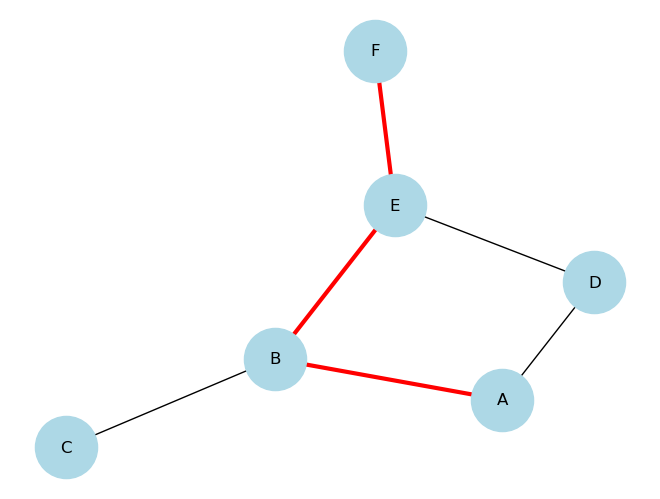

In [74]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

for node in graph:
    for neighbor in graph[node]:
        G.add_edge(node, neighbor)

pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000)

# Highlight Bi-BFS path
edges_in_path = list(zip(bidir_path, bidir_path[1:]))
nx.draw_networkx_edges(G, pos, edgelist=edges_in_path, edge_color='red', width=3)

plt.show()

